#  obs: de pendendo de onde estaja rodando vai ter que trocar o ambiente do notebook


In [8]:
!nvidia-smi
!rocminfo


/usr/bin/bash: line 1: nvidia-smi: command not found
ROCk module is loaded
HSA System Attributes    
Runtime Version:         1.18
Runtime Ext Version:     1.15
System Timestamp Freq.:  1000.000000MHz
Sig. Max Wait Duration:  18446744073709551615 (0xFFFFFFFFFFFFFFFF) (timestamp count)
Machine Model:           LARGE                              
System Endianness:       LITTLE                             
Mwaitx:                  DISABLED
XNACK enabled:           NO
DMAbuf Support:          YES
VMM Support:             YES

HSA Agents               
*******                  
Agent 1                  
*******                  
  Name:                    AMD Ryzen 5 5600GT with Radeon Graphics
  Uuid:                    CPU-XX                             
  Marketing Name:          AMD Ryzen 5 5600GT with Radeon Graphics
  Vendor Name:             CPU                                
  Feature:                 None specified                     
  Profile:                 FULL_PROFILE     

In [1]:

import os

os.environ["ROCR_VISIBLE_DEVICES"] = "0"
os.environ["HIP_VISIBLE_DEVICES"] = "0"
os.environ["HSA_OVERRIDE_GFX_VERSION"] = "10.3.0"
#os.environ["TF_FORCE_GPU_ALLOW_GROWTH"] = "true"

import tensorflow as tf
print("\n--- Validação TensorFlow ---")
gpus = tf.config.list_physical_devices('GPU')
print("GPUs detectadas pelo TensorFlow:", gpus)

2026-10-02 12:45:14.715146: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE3 SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.



--- Validação TensorFlow ---
GPUs detectadas pelo TensorFlow: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [1]:
import gc
import time

import numpy as np
import tensorflow as tf


def _eh_erro_de_memoria(e):
    # Em ROCm o OOM às vezes vem como InternalError/UnknownError em vez de ResourceExhaustedError
    if isinstance(e, tf.errors.ResourceExhaustedError):
        return True
    msg = str(e).lower()
    return any(t in msg for t in ("out of memory", "oom", "hipmalloc", "failed to allocate"))


def medir_batch_size(construir_modelo, x, y, batch_inicial=32, batch_limite=65536,
                     passos=20, aquecimento=3, ganho_minimo=0.05, parar_em_plato=True):
    """
    construir_modelo: função sem argumentos que devolve um modelo JÁ COMPILADO.
    x, y: dados reais (ou sintéticos) usados só para amostrar os batches.
    Retorna (maior_batch_que_coube, batch_com_melhor_throughput, resultados).
    """
    resultados = {}   # batch -> amostras/s
    maior_ok = 0
    batch = batch_inicial
    anterior = 0.0

    while batch <= batch_limite:
        tf.keras.backend.clear_session()
        gc.collect()
        try:
            modelo = construir_modelo()
            idx = np.random.randint(0, len(x), batch)
            xb, yb = x[idx].astype("float32"), y[idx]

            for _ in range(aquecimento):          # compila o grafo e aloca buffers
                modelo.train_on_batch(xb, yb)

            t0 = time.perf_counter()
            for _ in range(passos):
                modelo.train_on_batch(xb, yb)     # devolve escalares => sincroniza com a GPU
            dt = time.perf_counter() - t0

            vazao = batch * passos / dt
            resultados[batch] = vazao
            maior_ok = batch
            print(f"batch {batch:>6}: OK  | {vazao:>12,.0f} amostras/s")

            if parar_em_plato and anterior and (vazao - anterior) / anterior < ganho_minimo:
                print(f"   ganho < {ganho_minimo:.0%}: throughput estagnou, parando aqui.")
                break
            anterior = vazao
        except Exception as e:
            if _eh_erro_de_memoria(e):
                print(f"batch {batch:>6}: estourou a memória")
                break
            raise
        finally:
            modelo = None
            gc.collect()

        batch *= 2

    melhor = max(resultados, key=resultados.get) if resultados else 0
    print("\n--- Resultado ---")
    print(f"Maior batch testado que coube: {maior_ok}")
    print(f"Batch com melhor throughput:   {melhor}")
    return maior_ok, melhor, resultados


if __name__ == "__main__":
    from tensorflow.keras.datasets import fashion_mnist
    from tensorflow.keras.layers import Dense, Flatten
    from tensorflow.keras.models import Sequential

    (x_train, y_train), _ = fashion_mnist.load_data()
    x_train = (x_train / 255.0).astype("float32")

    def construir():
        m = Sequential([
            tf.keras.Input(shape=(28, 28)),
            Flatten(),
            Dense(128, activation="relu"),
            Dense(256, activation="relu"),
            Dense(128, activation="relu"),
            Dense(256, activation="relu"),
            Dense(96, activation="relu"),
            Dense(10, activation="softmax"),
        ])
        m.compile(optimizer="adam", loss="sparse_categorical_crossentropy",
                  metrics=["accuracy"])
        return m

    medir_batch_size(construir, x_train, y_train)

2026-10-02 13:24:57.335385: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE3 SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1790958300.296793  325399 gpu_device.cc:2396] Ignoring visible gpu device (device: 0, name: AMD Radeon RX 6600, pci bus id: 0000:03:00.0) with AMDGPU version : gfx1032. The supported AMDGPU versions are gfx900, gfx906, gfx908, gfx90a, gfx942, gfx950, gfx1030, gfx1100, gfx1101, gfx1102, gfx1150, gfx1151, gfx1200, gfx1201.


batch     32: OK  |       15,814 amostras/s
batch     64: OK  |       26,965 amostras/s
batch    128: OK  |       47,686 amostras/s
batch    256: OK  |       70,729 amostras/s
batch    512: OK  |       95,876 amostras/s
batch   1024: OK  |       99,932 amostras/s
   ganho < 5%: throughput estagnou, parando aqui.

--- Resultado ---
Maior batch testado que coube: 1024
Batch com melhor throughput:   1024



--- Validação TensorFlow ---
GPUs detectadas pelo TensorFlow: []
📊 --- Análise Matemática de VRAM ---
• Parâmetros do Modelo: 55,050
• Peso do Modelo na VRAM: 0.21 MB
• Ativação por amostra: 0.0000 MB
• Batch Size Máximo sugerido (Potência de 2): 268435456
Epoch 1/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5760 - loss: 13.4779 - val_accuracy: 0.7818 - val_loss: 2.5872
Epoch 2/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8033 - loss: 1.9511 - val_accuracy: 0.8255 - val_loss: 1.4826
Epoch 3/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8363 - loss: 1.2250 - val_accuracy: 0.8464 - val_loss: 1.1024
Epoch 4/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8552 - loss: 0.9108 - val_accuracy: 0.8592 - val_loss: 0.8967
Epoch 5/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8698 - loss: 0.7246 - val_accuracy: 0.8683 - val_loss: 0.7684
Epoch 6/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8826 - loss: 0.6014 - val_accuracy: 0.877

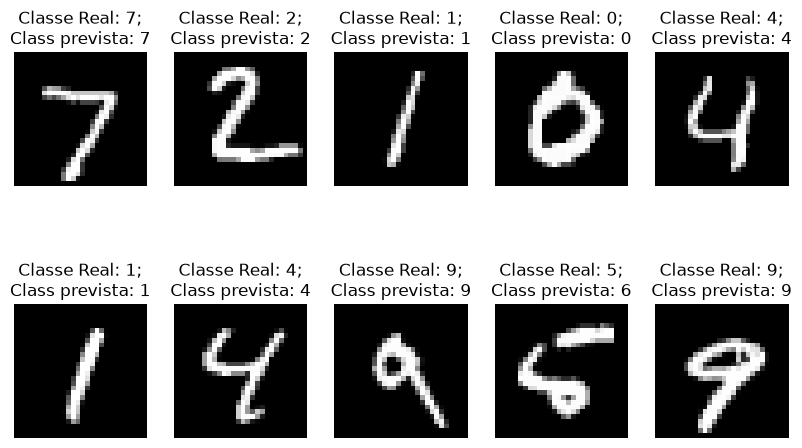

In [ ]:

import os

os.environ["ROCR_VISIBLE_DEVICES"] = "0"
os.environ["HIP_VISIBLE_DEVICES"] = "0"
os.environ["HSA_OVERRIDE_GFX_VERSION"] = "10.3.0"
#os.environ["TF_FORCE_GPU_ALLOW_GROWTH"] = "true"


import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Input
from tensorflow.keras.datasets import mnist


print("\n--- Validação TensorFlow ---")
gpus = tf.config.list_physical_devices('GPU')
print("GPUs detectadas pelo TensorFlow:", gpus)

model = Sequential([
    tf.keras.Input(shape=(28, 28)),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation="softmax"),
])



model.compile(
  optimizer="adam",
  loss='sparse_categorical_crossentropy',
  metrics=['accuracy']
)

(x_train, y_train), (x_test, y_test) = mnist.load_data()

history = model.fit(
  x_train,
  y_train,
  epochs=100,
  batch_size=500,
  validation_split=0.2
)


model.save("mlp_mnist_model.keras")

test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"Acurácia no conjunto de teste: {test_acc * 100:.2f}%")

preditor = model.predict(x_test[:10])

plt.figure(figsize=(10, 6))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(x_test[i], cmap='gray')
    plt.title(f"Classe Real: {y_test[i]};\nClass prevista: {np.argmax(preditor[i])}")
    plt.axis('off')
plt.show()

2026-10-02 13:29:44.527273: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE3 SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.



--- Validação TensorFlow ---
GPUs detectadas pelo TensorFlow: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


I0000 00:00:1790958587.419390  330286 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 6920 MB memory:  -> device: 0, name: AMD Radeon RX 6600, pci bus id: 0000:03:00.0


Epoch 1/100


2026-10-02 13:29:48.913650: I external/local_xla/xla/service/service.cc:163] XLA service 0x7f1b0000a760 initialized for platform ROCM (this does not guarantee that XLA will be used). Devices:
2026-10-02 13:29:48.913664: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): AMD Radeon RX 6600, AMDGPU ISA version: gfx1030
2026-10-02 13:29:48.931547: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.


...

300/313 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8749 - loss: 0.8474

2026-10-02 13:31:53.092042: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.


313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 16ms/step - accuracy: 0.8758 - loss: 0.8328
Acurácia no conjunto de teste: 87.58%


2026-10-02 13:31:57.142255: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-10-02 13:31:57.142290: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.


1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step


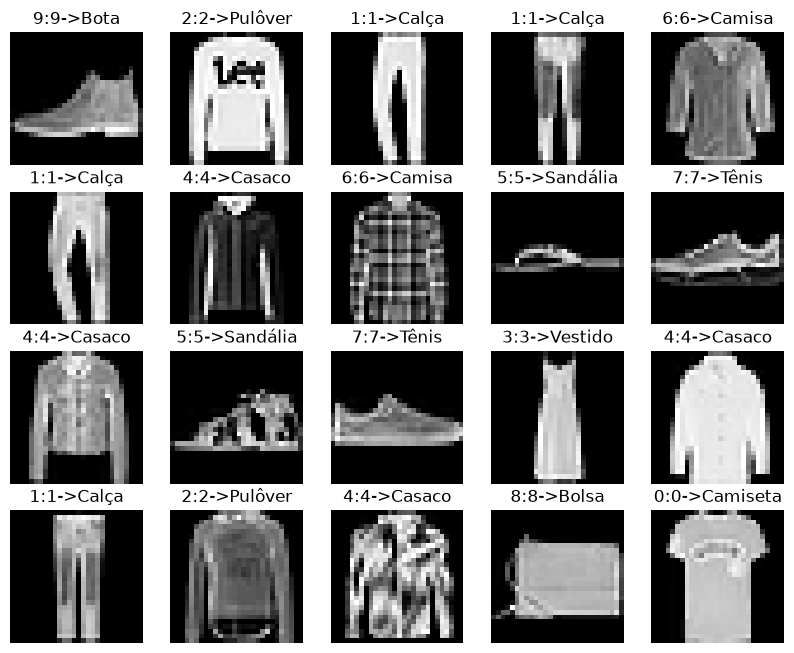

In [1]:

import os
import sys

os.environ["ROCR_VISIBLE_DEVICES"] = "0"
os.environ["HIP_VISIBLE_DEVICES"] = "0"
os.environ["HSA_OVERRIDE_GFX_VERSION"] = "10.3.0"
# os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"


import tensorflow as tf
print("\n--- Validação TensorFlow ---")
gpus = tf.config.list_physical_devices('GPU')
print("GPUs detectadas pelo TensorFlow:", gpus)


import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Input
from tensorflow.keras.datasets import fashion_mnist

(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

x_train = x_train / 255.0
x_test = x_test / 255.0


tf.keras.utils.set_random_seed(42)
tf.random.set_seed(42)


model = Sequential([
    tf.keras.Input(shape=(28, 28)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dense(256, activation='relu'),
    Dense(96, activation='relu'),
    Dense(10, activation="softmax"),
])

model.compile(
  optimizer="adam",
  loss='sparse_categorical_crossentropy',
  metrics=['accuracy']
)



history = model.fit(
  x_train,
  y_train,
  epochs=100,
  batch_size=256,
  validation_split=0.2
)


CLASSES = ['Camiseta', 'Calça', 'Pulôver', 'Vestido', 'Casaco', 'Sandália',
           'Camisa', 'Tênis', 'Bolsa', 'Bota']


test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"Acurácia no conjunto de teste: {test_acc * 100:.2f}%")

preditor = model.predict(x_test[:20])

plt.figure(figsize=(10, 10))
for i in range(20):
    plt.subplot(5, 5, i+1)
    plt.grid(False)
    plt.imshow(x_test[i], cmap='gray')
    plt.title(f"{y_test[i]}:{np.argmax(preditor[i])}->{CLASSES[np.argmax(preditor[i])]}")
    plt.axis('off')
plt.show()


Epoch 1/100
212/212 ━━━━━━━━━━━━━━━━━━━━ 1s 775us/step - loss: 0.4456
Epoch 2/100
212/212 ━━━━━━━━━━━━━━━━━━━━ 0s 626us/step - loss: 0.2982
Epoch 3/100
212/212 ━━━━━━━━━━━━━━━━━━━━ 0s 639us/step - loss: 0.2100
Epoch 4/100
212/212 ━━━━━━━━━━━━━━━━━━━━ 0s 633us/step - loss: 0.1881
Epoch 5/100
212/212 ━━━━━━━━━━━━━━━━━━━━ 0s 630us/step - loss: 0.1878
Epoch 6/100
212/212 ━━━━━━━━━━━━━━━━━━━━ 0s 628us/step - loss: 0.1800
Epoch 7/100
212/212 ━━━━━━━━━━━━━━━━━━━━ 0s 656us/step - loss: 0.1804
Epoch 8/100
212/212 ━━━━━━━━━━━━━━━━━━━━ 0s 647us/step - loss: 0.1680
Epoch 9/100
212/212 ━━━━━━━━━━━━━━━━━━━━ 0s 652us/step - loss: 0.1559
Epoch 10/100
212/212 ━━━━━━━━━━━━━━━━━━━━ 0s 654us/step - loss: 0.1382
Epoch 11/100
212/212 ━━━━━━━━━━━━━━━━━━━━ 0s 636us/step - loss: 0.1084
Epoch 12/100
212/212 ━━━━━━━━━━━━━━━━━━━━ 0s 651us/step - loss: 0.0755
Epoch 13/100
212/212 ━━━━━━━━━━━━━━━━━━━━ 0s 628us/step - loss: 0.0471
Epoch 14/100
212/212 ━━━━━━━━━━━━━━━━━━━━ 0s 643us/step - loss: 0.0244
Epoch 15/100
21

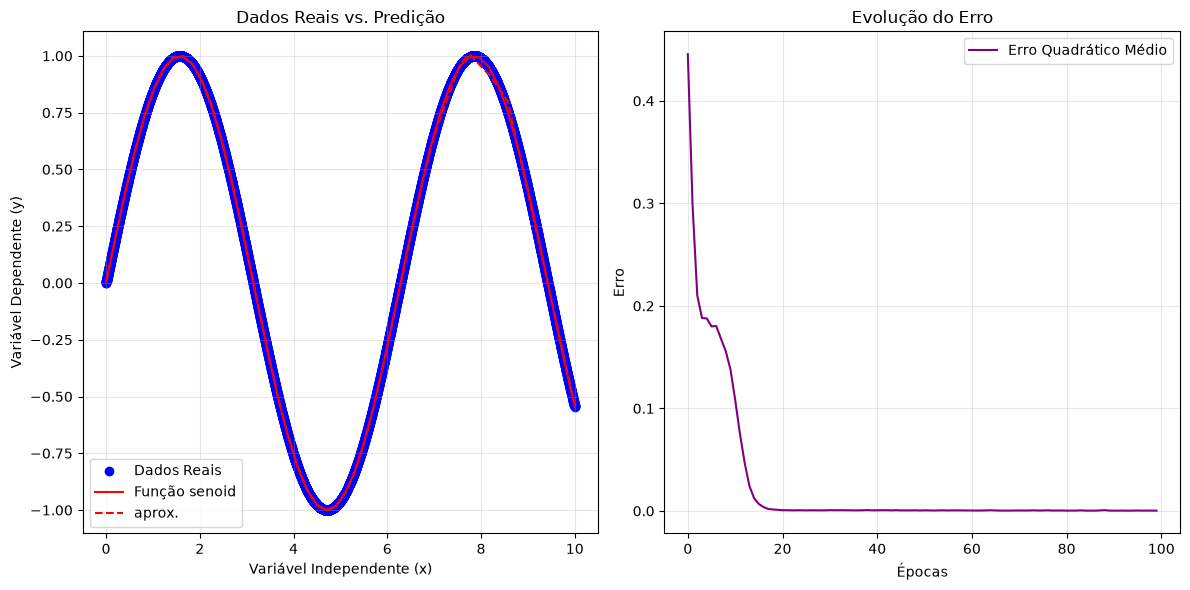

: 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Input


x =  np.linspace(0, 10, 6767)
y_real = np.sin(x)

w = np.random.randn(1)
b = np.random.randn(1)

model = Sequential([
    tf.keras.Input(shape=(1,)),
    Dense(64, activation='relu'),
    Dense(64, activation='relu'),
    Dense(1),
])

model.compile(
  optimizer="adam",
  loss='mean_squared_error'
)

history = model.fit(
  x,
  y_real,
  epochs=100,
  batch_size=500
)

X_range = np.linspace(0, 10)
Y_range = np.sin(X_range)
y_pred = model.predict(X_range)

weights, biases = model.layers[0].get_weights()

print(f"Peso: {weights[0][0]:.2f}")
print(f"Bias: {biases[0]:.2f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

ax1.scatter(x, y_real, color='blue', label='Dados Reais')
ax1.plot(X_range, Y_range, color='red', label='Função senoid')
ax1.plot(X_range, y_pred, "--", color='red', label='aprox.')
ax1.set_xlabel('Variável Independente (x)')
ax1.set_ylabel('Variável Dependente (y)')
ax1.set_title('Dados Reais vs. Predição')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(history.history['loss'], label='Erro Quadrático Médio', color='purple')
ax2.set_xlabel('Épocas')
ax2.set_ylabel('Erro')
ax2.set_title('Evolução do Erro')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()